# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
data = pd.read_csv(file_path)

data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

categorical_columns = ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

X = data.drop('Credit_Score', axis=1).values
y = data['Credit_Score'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class CreditScoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = CreditScoreDataset(X_train, y_train)
test_dataset = CreditScoreDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


input_size = X_train.shape[1]
model = MLP(input_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')


Epoch [1/20], Loss: 0.6881, 학습 정확도: 68.50%, 평가 정확도: 69.90%
Epoch [2/20], Loss: 0.6517, 학습 정확도: 70.28%, 평가 정확도: 70.29%
Epoch [3/20], Loss: 0.6416, 학습 정확도: 70.70%, 평가 정확도: 70.51%
Epoch [4/20], Loss: 0.6355, 학습 정확도: 70.95%, 평가 정확도: 69.99%
Epoch [5/20], Loss: 0.6309, 학습 정확도: 71.13%, 평가 정확도: 70.95%
Epoch [6/20], Loss: 0.6266, 학습 정확도: 71.44%, 평가 정확도: 70.44%
Epoch [7/20], Loss: 0.6234, 학습 정확도: 71.49%, 평가 정확도: 70.87%
Epoch [8/20], Loss: 0.6203, 학습 정확도: 71.62%, 평가 정확도: 70.70%
Epoch [9/20], Loss: 0.6167, 학습 정확도: 71.63%, 평가 정확도: 70.72%
Epoch [10/20], Loss: 0.6152, 학습 정확도: 71.78%, 평가 정확도: 70.85%
Epoch [11/20], Loss: 0.6119, 학습 정확도: 72.04%, 평가 정확도: 71.11%
Epoch [12/20], Loss: 0.6093, 학습 정확도: 72.17%, 평가 정확도: 71.11%
Epoch [13/20], Loss: 0.6071, 학습 정확도: 72.26%, 평가 정확도: 71.39%
Epoch [14/20], Loss: 0.6052, 학습 정확도: 72.36%, 평가 정확도: 70.98%
Epoch [15/20], Loss: 0.6030, 학습 정확도: 72.38%, 평가 정확도: 71.48%
Epoch [16/20], Loss: 0.6002, 학습 정확도: 72.59%, 평가 정확도: 71.44%
Epoch [17/20], Loss: 0.5980, 학습 정확도: 72.66%, 평가 정

# 딥러닝 컴페티션 코드

In [5]:
!pip install tab_transformer_pytorch

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  int64  
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              100000 non-null  ob

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


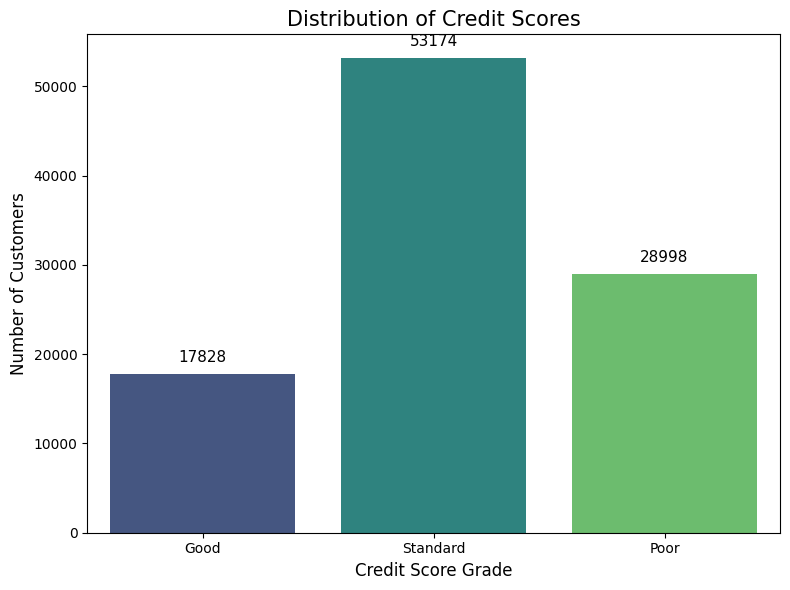

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train2.csv')

# Credit_Score 등급별 개수 세기
score_counts = df['Credit_Score'].value_counts()
print(score_counts)

# 그래프 세팅
plt.figure(figsize=(8, 6))

# 막대그래프 생성
sns.barplot(
    x=['Good', 'Standard', 'Poor'],
    y=score_counts[['Good', 'Standard', 'Poor']].values,
    palette='viridis'
)

# 그래프
plt.title('Distribution of Credit Scores', fontsize=15)
plt.xlabel('Credit Score Grade', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

for i, v in enumerate(score_counts[['Good', 'Standard', 'Poor']]):
    plt.text(i, v + 1000, str(v), ha='center', va='bottom', fontsize=11)

# 7. 출력
plt.tight_layout()
plt.show()

In [7]:
import torch
import torch.nn as nn
from tab_transformer_pytorch import TabTransformer
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader
import copy
import warnings

warnings.simplefilter("ignore")

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"현재 사용 중인 Device: {device}")

# 데이터 불러오기
df = pd.read_csv('train2.csv')

# 파생 변수 설정 # 1e-5 -> 분모가 0이 되는 걸 방지하기 위해 사용

# 부채 비율 # 총 남은 부채 ÷ 연간 총소득
df['Debt_to_Income_Ratio'] = df['Outstanding_Debt'] / (df['Annual_Income'] + 1e-5)
# 상환 부담 비율 # 월별 대출 원리금 상환액 ÷ 월 실수령액
df['EMI_to_Salary_Ratio'] = df['Total_EMI_per_month'] / (df['Monthly_Inhand_Salary'] + 1e-5)
# 투자 성향 비율 # 월 최종 잔고 ÷ 월 실수령액
df['Balance_to_Salary_Ratio'] = df['Monthly_Balance'] / (df['Monthly_Inhand_Salary'] + 1e-5)

# 실질 가처분 소득 # 월 실수령액 - 월 대출 상환액 - 월 투자 금액
df['Disposable_Income'] = df['Monthly_Inhand_Salary'] - df['Total_EMI_per_month'] - df['Amount_invested_monthly']

# 급여 대비 투자 비율 # 월 투자 금액 ÷ 월 실수령액
df['Investment_to_Salary_Ratio'] = df['Amount_invested_monthly'] / (df['Monthly_Inhand_Salary'] + 1e-5)

# 총 금융 창구 수 # 은행 계좌 수 + 신용카드 수 + 대출 건수
df['Total_Financial_Lines'] = df['Num_Bank_Accounts'] + df['Num_Credit_Card'] + df['Num_of_Loan']

# 창구당 평균 부채 # 총 남은 부채 ÷ 총 금융 접점 수
df['Average_Debt_per_Line'] = df['Outstanding_Debt'] / (df['Total_Financial_Lines'] + 1e-5)

# 나이 대비 신용 이력 # 신용 이력 연수 ÷ 나이
df['Credit_History_to_Age_Ratio'] = (df['Credit_History_Age'] / 12) / (df['Age'] + 1e-5)

# 연체 심각도 # 연체된 일수 × 연체 횟수
df['Delay_Severity'] = df['Delay_from_due_date'] * df['Num_of_Delayed_Payment']

# 불필요한 컬럼 삭제 및 결측치 처리
drop_cols = ['ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan']
df.drop(columns=drop_cols, inplace=True)
df = df.dropna(how="any")

# Credit_Score 제외 나머지 사용
X = df.drop(columns=['Credit_Score'])
# 정답지
y = LabelEncoder().fit_transform(df['Credit_Score'])
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 범주형 변수 리스트 생성 -> 연속형 변수 자동 추출
cat_cols = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
cont_cols = [c for c in X.columns if c not in cat_cols]

# 연속형 스케일링
scaler = StandardScaler()
X_train_cont = scaler.fit_transform(X_train[cont_cols])
X_test_cont = scaler.transform(X_test[cont_cols])

# 범주형 인코딩
ordinal_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Unknown 분리를 위한 +1 Shift 적용
# 정상 범주는 1부터 시작하고, Unknown(-1)은 0이 되어 완전히 독립적인 인덱스를 보유
X_train_cat = ordinal_enc.fit_transform(X_train[cat_cols]) + 1
X_test_cat = ordinal_enc.transform(X_test[cat_cols]) + 1
X_test_cat = np.maximum(X_test_cat, 0)

cat_dims = tuple(int(x) for x in X_train_cat.max(axis=0) + 1)

# 미니배치
# 범주형과 연속형 데이터를 찢어서 변환
train_dataset = TensorDataset(
    torch.tensor(X_train_cat, dtype=torch.int64),
    torch.tensor(X_train_cont, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

test_dataset = TensorDataset(
    torch.tensor(X_test_cat, dtype=torch.int64),
    torch.tensor(X_test_cont, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# TabTransformer 모델 정의
model = TabTransformer(
    categories=cat_dims, # 유니크 값을 수동으로 넣지 않고 자동으로 변경
    num_continuous=len(cont_cols), # 연속형 변수의 개수
    dim=32, # 모델 차원
    dim_out=3, # 이진 분류 출력
    depth=6, # 모델 깊이
    heads=8, # 멀티헤드 어텐션 헤드 수
    attn_dropout=0.1, # 어텐션 드롭아웃
    ff_dropout=0.1, # 피드포워드 드롭아웃
    mlp_hidden_mults=(4, 2), # MLP의 히든 레이어 크기 비율
    mlp_act=nn.ReLU(), # MLP의 활성화 함수
).to(device) # 디바이스 이동

# 클래스 고유값 추출
classes = np.unique(y_train)
# 가중치 계산
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
# 파이토치 텐서 변환
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device) # Device 이동

# 손실함수
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
# Adam 사용 및 학습률 0.001로 설정
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# N번 반복
num_epochs = 100

# 최상의 정확도를 저장
best_acc = 0.0
# 가중치를 저장
best_model_weights = None

print("\nStarting Training & Validation...")
for epoch in range(num_epochs):

    # 학습 선언
    model.train()
    # 손실 보관
    total_loss = 0
    # 배치 데이터
    for batch_cat, batch_cont, batch_y in train_loader:
        # GPU로 전송
        batch_cat = batch_cat.to(device)
        batch_cont = batch_cont.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad() # 기울기 초기화
        y_pred = model(batch_cat, batch_cont) # 예측 및 손실 계산
        loss = criterion(y_pred, batch_y) # 오차 계산
        loss.backward() # 역전파
        optimizer.step() # 가중치 업데이트
        total_loss += loss.item() # 총점 누적

    avg_train_loss = total_loss / len(train_loader)

    # 모델 평가
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad(): # 기울기 계산 X
        # GPU로 이동
        for batch_cat, batch_cont, batch_y in test_loader:
            batch_cat = batch_cat.to(device)
            batch_cont = batch_cont.to(device)

            # 예측
            val_pred = model(batch_cat, batch_cont)
            val_pred_class = torch.argmax(val_pred, dim=1)
            # 결과 데이터 수집
            all_preds.extend(val_pred_class.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    # 정확도 계산
    val_acc = accuracy_score(all_targets, all_preds)

    # 최상의 모델 기록
    is_best = ""
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())
        is_best = " (Best Score)"
    # 출력
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Valid Acc: {val_acc:.4f}{is_best}")

# 최상의 모델로 복원
model.load_state_dict(best_model_weights)
print(f"\nTraining Complete! Best Valid Accuracy Restored: {best_acc:.4f}")

현재 사용 중인 Device: cuda

Starting Training & Validation...
Epoch 01/100 | Train Loss: 0.7526 | Valid Acc: 0.6615 (Best Score)
Epoch 05/100 | Train Loss: 0.6448 | Valid Acc: 0.6772
Epoch 10/100 | Train Loss: 0.5884 | Valid Acc: 0.6915 (Best Score)
Epoch 15/100 | Train Loss: 0.4489 | Valid Acc: 0.7290 (Best Score)
Epoch 20/100 | Train Loss: 0.3017 | Valid Acc: 0.7733 (Best Score)
Epoch 25/100 | Train Loss: 0.2070 | Valid Acc: 0.7859 (Best Score)
Epoch 30/100 | Train Loss: 0.1474 | Valid Acc: 0.7820
Epoch 35/100 | Train Loss: 0.1076 | Valid Acc: 0.7762
Epoch 40/100 | Train Loss: 0.0801 | Valid Acc: 0.7718
Epoch 45/100 | Train Loss: 0.0667 | Valid Acc: 0.7726
Epoch 50/100 | Train Loss: 0.0540 | Valid Acc: 0.7747
Epoch 55/100 | Train Loss: 0.0460 | Valid Acc: 0.7721
Epoch 60/100 | Train Loss: 0.0437 | Valid Acc: 0.7684
Epoch 65/100 | Train Loss: 0.0455 | Valid Acc: 0.7699
Epoch 70/100 | Train Loss: 0.0333 | Valid Acc: 0.7735
Epoch 75/100 | Train Loss: 0.0387 | Valid Acc: 0.7741
Epoch 80/100 |

**1. 전처리 아이디어 적합성 + 논리**

크게 수입 대비 부담도 (부채 비율, 상환 부담 비율), 실질적인 현금 흐름 (가처분 소득, 잔고 비중, 투자 성향 비율), 창구 분석 (총 금융 창구 수, 창구당 평균 부채), 성숙도 확인 (나이 대비 신용 이력, 연체 심각도)를 활용하여 총 9개의 파생변수를 만들어 성능을 극대화 하였습니다.
신용평가는 상대적인 비율과 금융을 어떻게 활용하는지를 볼 수 있는 습관이 중요하다고 생각합니다. 그래서 딥러닝 모델이 스스로 학습하기 어려운 비율이나 곱셈을 도메인에 기반하여 정의하였습니다.



**2. EDA를 통한 타당한 해석**

EDA를 통해 데이터가 다중 분류이고 클래스 간에 불균형이 존재함을 파악하였습니다.
이를 해소하기 위해 학습 가중치를 부여하였고, 스케일링을 통해 모든 수치형 피처를 정규화하였습니다.
또한, Credit_Score가 3개의 등급으로 구성되어 있기에 출력층을 3개로 설정하였습니다.



**3. Feature Selection과 모델 선택, 튜닝 기준**

'ID', 'Customer_ID', 'Name', 'SSN'와 노이즈가 강하다고 보이는 비정형인 'Type_of_Loan'를 제거하여 성능을 높였고, 범주형은 5개, 연속형은 20여 종의 변수(파생변수 포함)를 최종적으로 선택하였습니다.
모델은 TabTransformer를 채택하였고, 유니크 값을 자동으로 설계하였고, heads와 depth를 각각 8과 6으로 설정해 모델의 복잡도를 확보하였습니다, 또한 과적합 방지를 위해 dropout을 0.1로 적용하였습니다.


**4. 개선사항**

먼저 고정된 학습률을 OPTUNA 등을 활용하여 최적을 조합을 찾을 수 있을 것으로 보입니다.
그리고 스케줄러를 도입한다면, 정체되는 순간에 보폭을 줄여 정답에 더욱 정교하게 다가갈 수 있을 것이라고 생각합니다.
마지막으로, 앙상블을 사용한다면 좀 더 구체적이고 복잡한 모델을 구축할 수 있다고 봅니다.



**5. validation score 적절하게 출력**

현재 출력된 validation score는 0.78로 목표인 0.75이상을 충족하여 적절한 score를 뽑았다고 볼 수 있습니다.